Goal: Use a ridge and lasso model to predict the ClosePrice of real estate. 
Ridge and Lasso utilizes regularization, which is adding a penalty to large coefficients so the model cannot overfit. Ridge is ideal when features are highly correlated and when less variance, more generalizaiton is needed. Lasso regression penalizes coefficients based on their absolute magnitutde. Lasso is ideal when only a few predictors matter. Ridge shrinks weights, Lasso shrinks and removes useless features. 

In [37]:
#final_traning.csv: training set (cleaned + processed)
#oct_testing.csv: holdout/final test set
#steps: load two datasets, separate x & y, scale features using training data, 
#fit ridge & lasso, evaluate on both train + test

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score
from sklearn.linear_model import RidgeCV, LassoCV

In [38]:
train = pd.read_csv("final_training.csv")
test = pd.read_csv("oct_testing.csv")

In [42]:
#Feature Engineering
def add_features(df):
    df = df.copy()

    # Price per square foot
    if "LivingArea" in df.columns:
        df["PricePerSqFt"] = df["ClosePrice"] / df["LivingArea"].replace(0, np.nan)

    # Total rooms
    if {"BedroomsTotal", "BathroomsTotalInteger"}.issubset(df.columns):
        df["TotalRooms"] = df["BedroomsTotal"] + df["BathroomsTotalInteger"]

    # House age (if YearBuilt exists)
    if "YearBuilt" in df.columns:
        df["HouseAge"] = 2025 - df["YearBuilt"]

    # Interaction feature: Beds * Sqft
    if {"BedroomsTotal", "LivingArea"}.issubset(df.columns):
        df["Beds_x_Sqft"] = df["BedroomsTotal"] * df["LivingArea"]

    return df

train = add_features(train)
test = add_features(test)

In [43]:
target = "ClosePrice"
numeric_cols = ['Latitude', 'Longitude', 'LivingArea', 'ParkingTotal', 'YearBuilt', 'BathroomsTotalInteger',
                'BedroomsTotal', 'Stories', 'PropertyAgeAtClose', 'GarageSpaces',
                'TotalRooms', 'HouseAge', 'Beds_x_Sqft']

In [44]:
X_train = train[numeric_cols]
y_train = train[target]
y_train_log = np.log1p(y_train)

X_test = test[numeric_cols]
y_test = test[target]
y_test_log = np.log1p(y_test)

In [45]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [46]:
low = y_test.quantile(0.005)
high = y_test.quantile(0.995)

mask = (y_test >= low) & (y_test <= high)

X_test_trim = X_test_scaled[mask]
y_test_trim = y_test[mask]
y_test_trim_log = y_test_log[mask]

In [51]:
#Ridge hyperparameter tuning
# 4. Ridge hyperparameter tuning
ridge_params = {"alpha": np.logspace(-2, 4, 50)}
ridge = GridSearchCV(Ridge(), ridge_params, cv=10)
ridge.fit(X_train_scaled, y_train_log)
ridge_pred_log = ridge.predict(X_test_trim)

# 5. Lasso hyperparameter tuning
lasso_params = {"alpha": np.logspace(-4, 2, 50)}
lasso = GridSearchCV(Lasso(max_iter=50000), lasso_params, cv=10)
lasso.fit(X_train_scaled, y_train_log)
lasso_pred_log = lasso.predict(X_test_trim)

ridge_pred = np.expm1(ridge_pred_log)
lasso_pred = np.expm1(lasso_pred_log)

In [52]:
def evaluate_model(name, y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
    mdape = np.median(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
    print(f"\n{name} Results")
    print("R²:", r2)
    print("MAPE:", mape)
    print("MdAPE:", mdape)

# 8. Evaluate both models
evaluate_model("Ridge (best alpha = {})".format(ridge.best_params_['alpha']),
               y_test_trim, ridge_pred)

evaluate_model("Lasso (best alpha = {})".format(lasso.best_params_['alpha']),
               y_test_trim, lasso_pred)


Ridge (best alpha = 790.6043210907702) Results
R²: 0.3931513674123428
MAPE: 33.69152577929326
MdAPE: 25.975581486345646

Lasso (best alpha = 0.0022229964825261957) Results
R²: 0.3915372714958867
MAPE: 33.742507433763826
MdAPE: 25.958589618225712


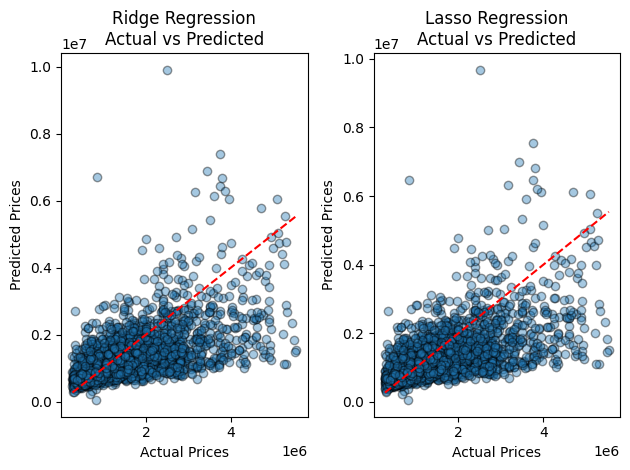

In [49]:
#Ridge
plt.subplot(1, 2, 1)
plt.scatter(y_test_trim, ridge_pred, alpha=0.4, edgecolors='k')
plt.plot([y_test_trim.min(), y_test_trim.max()],
         [y_test_trim.min(), y_test_trim.max()], 'r--')
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Ridge Regression\nActual vs Predicted")

#Lasso
plt.subplot(1, 2, 2)
plt.scatter(y_test_trim, lasso_pred, alpha=0.4, edgecolors='k')
plt.plot([y_test_trim.min(), y_test_trim.max()],
         [y_test_trim.min(), y_test_trim.max()], 'r--')
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Lasso Regression\nActual vs Predicted")

plt.tight_layout()
plt.show()

My linear regression model: 
R²: 0.087
MAPE: 54.62
MdAPE: 36.15


New Ridge & Lasso Model: R² = 0.39 --> less than before
My model explains 39% of the variation in closing prices. 61% of the price variation is unexplained by this linear model. The relationship between features and home price is more complex than a linear model can represent.

MAPE = 33.7% --> error is better than before
On average, my model is off by 33.7% of the true price. 

MdAPE = 26%
Half of predictions are within 26% of actual price. For a typical home, the model is about 26% off. This is better than MAPE because extreme luxury homes no longer dominate the error.

Overall, the performance didn't improve much even after data feature engineering, transforming to log, etc. This is because linear models cannot capture nonlinear location effects, neighborhood clusters, nonlinear relationships between sqft, beds, baths. This requires more feature engineering or nonlinear models. 